# Gulf Stream CHL & ADT Climatology

NOTE: This was not run on CryoCloud due to the file sizes of the original satellite data. 

This script takes CHLA and SLA satelltie data from 2000-2020, calculates monthly averages, crops to the Gulf Stream region, interpolates them to the same 1/4 degree grids, and saves the data as an xarray dataset. 

OLD GRID: 

lon_min,lon_max = 280, 300
lat_min,lat_max = 32, 42

NEW GRID (expanded lon): 

lon_min,lon_max = 280, 320


Engaging pool directory changed to (11/2025): `/home/jonesae/orcd/pool/PACEhackweek/`


_____


LJK

Date created: 04/21/25

Last edited: 11/07/25

In [1]:
import os
import numpy as np
from netCDF4 import Dataset
import xarray as xr
import matplotlib.pyplot as plt
#from sklearn.cluster import KMeans


In [2]:
fontsize = 18

plt.rc('font', size=fontsize)          # controls default text sizes
plt.rc('axes', titlesize=fontsize)     # fontsize of the axes title
plt.rc('axes', labelsize=fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('ytick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('legend', fontsize=fontsize)    # legend fontsize
plt.rc('figure', titlesize=fontsize)  # fontsize of the figure title

In [3]:
#input_dir = '/nfs/micklab005/jonesae/gradients4/CMEMS_data/'
input_dir = '/nfs/micklab005/jonesae/NP_2000_to_2020/CMEMS_data/'

# Set up empty array to add the daily SLA 
#sample_sla = xr.open_dataset(input_dir + 'dt_global_allsat_phy_l4_20210101.nc')
sample_sla = xr.open_dataset(input_dir + 'dt_global_allsat_phy_l4_20130412.nc')
sample_sla

<xarray.Dataset>
Dimensions:    (latitude: 720, longitude: 1440, nv: 2, time: 1)
Coordinates:
  * time       (time) datetime64[ns] 2013-04-12
  * latitude   (latitude) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * longitude  (longitude) float32 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
  * nv         (nv) int32 0 1
Data variables:
    crs        int32 ...
    lat_bnds   (latitude, nv) float32 ...
    lon_bnds   (longitude, nv) float32 ...
    err        (time, latitude, longitude) float64 ...
    adt        (time, latitude, longitude) float64 ...
    ugos       (time, latitude, longitude) float64 ...
    vgos       (time, latitude, longitude) float64 ...
    sla        (time, latitude, longitude) float64 ...
    ugosa      (time, latitude, longitude) float64 ...
    vgosa      (time, latitude, longitude) float64 ...
Attributes:
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    creator_name:                    CMEMS - Sea Level Thematic Assembly Center
    creator_url:                     http://marine.copernicus.eu
    date_created:                    2019-01-17T23:06:48Z
    date_issued:                     2019-01-17T23:06:48Z
    date_modified:                   2019-01-17T23:06:48Z
    geospatial_lat_max:              89.875
    geospatial_lat_min:              -89.875
    geospatial_lat_resolution:       0.25
    geospatial_lat_units:            degrees_north
    geospatial_lon_max:              359.875
    geospatial_lon_min:              0.125
    geospatial_lon_resolution:       0.25
    geospatial_lon_units:            degrees_east
    geospatial_vertical_max:         0.0
    geospatial_vertical_min:         0.0
    geospatial_vertical_positive:    down
    geospatial_vertical_resolution:  point
    geospatial_vertical_units:       m
    history:                         2019-01-17 23:06:49Z: Creation
    institution:                     CLS, CNES
    keywords:                        Oceans > Ocean Topography > Sea Surface ...
    keywords_vocabulary:             NetCDF COARDS Climate and Forecast Stand...
    license:                         http://marine.copernicus.eu/web/27-servi...
    platform:                        Altika, Cryosat-2, Jason-1 Geodetic Phas...
    processing_level:                L4
    product_version:                 2019
    project:                         COPERNICUS MARINE ENVIRONMENT MONITORING...
    references:                      http://marine.copernicus.eu
    software_version:                6.2_DUACS_DT2018_baseline
    source:                          Altimetry measurements
    ssalto_duacs_comment:            The reference mission used for the altim...
    standard_name_vocabulary:        NetCDF Climate and Forecast (CF) Metadat...
    summary:                         SSALTO/DUACS Delayed-Time Level-4 sea su...
    time_coverage_duration:          P1D
    time_coverage_end:               2013-04-12T00:00:00Z
    time_coverage_resolution:        P1D
    time_coverage_start:             2013-04-12T00:00:00Z
    title:                           DT merged all satellites Global Ocean Gr...

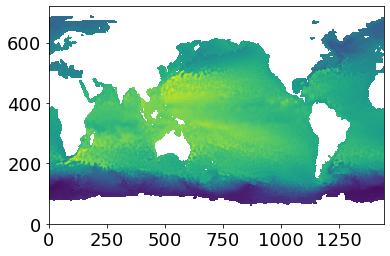

In [4]:
plt.pcolormesh(sample_sla.adt[0])

Dimension edges is just used to properly plot with pcolormesh

In [5]:
def dimension_edges(dim_array):
    adjustment = float(dim_array[1]-dim_array[0])/2
    adjusted_array = [float(i)-adjustment for i in dim_array]
    adjusted_array.append(dim_array[-1]+adjustment)
    return np.array(adjusted_array)

In [6]:
sample_sla_lon_edges = dimension_edges(sample_sla.longitude)
sample_sla_lat_edges = dimension_edges(sample_sla.latitude)

lon_min,lon_max = 280, 320
lat_min,lat_max = 32, 42

lon_inds = np.where((sample_sla_lon_edges >= lon_min) & (sample_sla_lon_edges <= lon_max))
lat_inds = np.where((sample_sla_lat_edges >= lat_min) & (sample_sla_lat_edges <= lat_max))

/home/jonesae/.conda/envs/py3_parcels_v2/lib/python3.6/site-packages/ipykernel_launcher.py:28: MatplotlibDeprecationWarning: The 'extend' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.


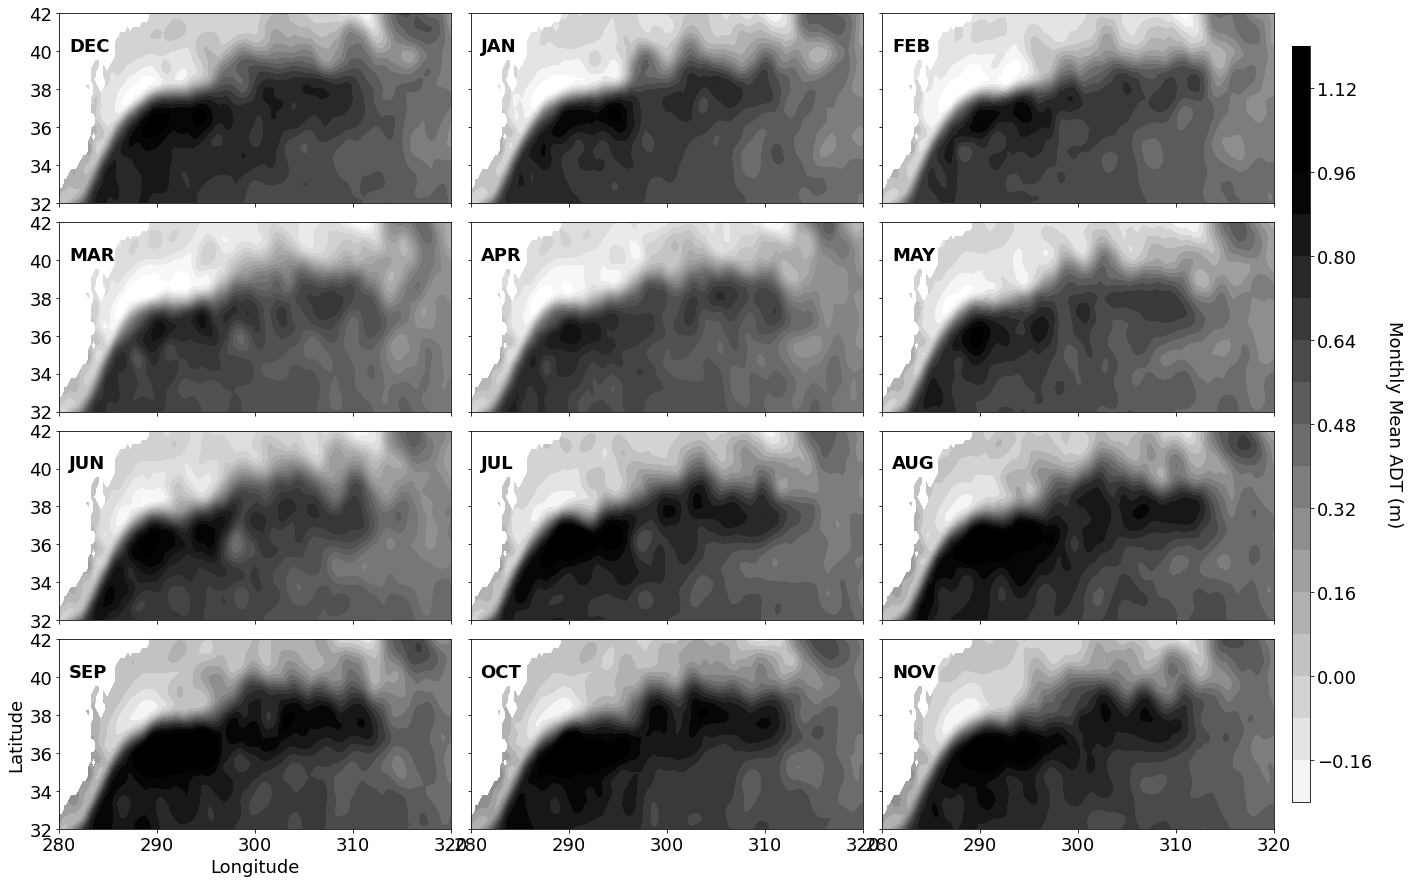

In [7]:
fig,ax = plt.subplots(4,3,figsize=(25,15))
plt.subplots_adjust(wspace=0.05, hspace=0.1) # make plots closer together

month_list = ['01','02','03','04','05','06','07','08','09','10','11','12']
months = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']

#ADT_avg = np.load('/nfs/micklab005/jonesae/NP_2000_to_2020/CMEMS_data/climatology/dt_global_allsat_phy_l4_2010_2019_month_01_AVG.npy')


def plot_row_by_season(row_ind,array_of_months):
    i = 0
    for m in array_of_months:
        ADT_avg = np.load('/nfs/micklab005/jonesae/NP_2000_to_2020/CMEMS_data/climatology/dt_global_allsat_phy_l4_2010_2019_month_%s_AVG.npy'%(m))
        plot = ax[row_ind,i].contourf(sample_sla_lon_edges[lon_inds],sample_sla_lat_edges[lat_inds],np.array(ADT_avg)[lat_inds[0],:][:,lon_inds[0]],
                                        cmap='binary',levels=20,vmin=-0.25,vmax=0.95)
        ax[row_ind,i].text(281,40,months[month_list.index(m)],color='k',fontweight='bold')
        i += 1
    return plot

plot = plot_row_by_season(0,['12','01','02']) # Winter
plot = plot_row_by_season(1,['03','04','05']) # Spring
plot = plot_row_by_season(2,['06','07','08']) # Summer
plot = plot_row_by_season(3,['09','10','11']) # Fall

# Colorbar
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.81, 0.15, 0.01, 0.7]) #[left, bottom, width, height]
fig.colorbar(plot, cax=cbar_ax, extend='both')
cbar_ax.set_ylabel('Monthly Mean ADT (m)', rotation=270)
cbar_ax.get_yaxis().labelpad = 30


ax[3,0].set_xlabel('Longitude')
ax[3,0].set_ylabel('Latitude')

for row in range(4):
    for col in range(3):
        if row != 3:
            ax[row,col].set_xticklabels([])
        if col != 0:
            ax[row,col].set_yticklabels([])

plt.show()

### OC-CCI Monthly Chl-a 

In [8]:
chl_dir = '/home/jonesae/orcd/pool/PACEhackweek/monthly_chl/' #'/pool001/jonesae/PACEhackweek/monthly_chl/'
sample_chl = xr.open_dataset(chl_dir + 'ESACCI-OC-L3S-CHLOR_A-MERGED-1M_MONTHLY_4km_GEO_PML_OCx-201612-fv6.0.nc')
sample_chl

<xarray.Dataset>
Dimensions:             (lat: 4320, lon: 8640, time: 1)
Coordinates:
  * lat                 (lat) float64 89.98 89.94 89.9 ... -89.9 -89.94 -89.98
  * lon                 (lon) float64 -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
  * time                (time) datetime64[ns] 2016-12-01
Data variables:
    MERIS_nobs_sum      (time, lat, lon) float32 ...
    MODISA_nobs_sum     (time, lat, lon) float32 ...
    OLCI-A_nobs_sum     (time, lat, lon) float32 ...
    OLCI-B_nobs_sum     (time, lat, lon) float32 ...
    SeaWiFS_nobs_sum    (time, lat, lon) float32 ...
    VIIRS_nobs_sum      (time, lat, lon) float32 ...
    chlor_a             (time, lat, lon) float32 ...
    chlor_a_log10_bias  (time, lat, lon) float32 ...
    chlor_a_log10_rmsd  (time, lat, lon) float32 ...
    crs                 int32 ...
    total_nobs_sum      (time, lat, lon) float32 ...
Attributes:
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    cdm_data_type:                     Grid
    comment:                           See summary attribute
    creator_email:                     help@esa-oceancolour-cci.org
    creator_name:                      Plymouth Marine Laboratory
    creator_url:                       http://esa-oceancolour-cci.org
    geospatial_lat_max:                90.0
    geospatial_lat_min:                -90.0
    geospatial_lat_resolution:         .04166666666666666666
    geospatial_lat_units:              decimal degrees north
    geospatial_lon_max:                180.0
    geospatial_lon_min:                -180.0
    geospatial_lon_resolution:         .04166666666666666666
    geospatial_lon_units:              decimal degrees east
    geospatial_vertical_max:           0.0
    geospatial_vertical_min:           0.0
    git_commit_hash:                   4db7bf1d93d4acce920d50186c81b2052007f64a
    institution:                       Plymouth Marine Laboratory
    keywords:                          satellite,observation,ocean,ocean colour
    keywords_vocabulary:               none
    naming_authority:                  uk.ac.pml
    number_of_bands_used_to_classify:  4
    number_of_optical_water_types:     14
    platform:                          Orbview-2,Aqua,Envisat,Suomi-NPP, Sent...
    processing_level:                  Level-3
    product_version:                   6.0
    sensor:                            SeaWiFS,MODIS,MERIS,VIIRS,OLCI
    sensors_present:                    MODISA OLCIa VIIRSN
    spatial_resolution:                4km nominal at equator
    standard_name_vocabulary:          NetCDF Climate and Forecast (CF) Metad...
    NCO:                               netCDF Operators version 4.7.5 (Homepa...
    number_of_files_composited:        31
    creation_date:                     Mon Aug 15 19:18:18 2022
    date_created:                      Mon Aug 15 19:18:18 2022
    time_coverage_resolution:          P1M
    time_coverage_duration:            P1M
    start_date:                        01-DEC-2016 00:00:00.000000
    stop_date:                         31-DEC-2016 23:59:00.000000
    time_coverage_start:               201612010000Z
    time_coverage_end:                 201612312359Z
    history:                           Source data were: ESACCI-OC-L3S-OC_PRO...
    netcdf_file_type:                  NETCDF4_CLASSIC
    id:                                ESACCI-OC-L3S-CHLOR_A-MERGED-1M_MONTHL...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    license:                           ESA CCI, EOCIS, and C3S Data Policy: f...
    project:                           Climate Change Initiative - European S...
    references:                        https://climate.esa.int/en/projects/oc...
    title:                             ESA CCI, EOCIS Ocean Colour Product, a...
    summary:                           Data products generated by the Ocean C...
    tracking_id:                       7dec76

This takes a hot min

In [9]:
chl_dir = '/home/jonesae/orcd/pool/PACEhackweek/monthly_chl/'
main_files = [f for f in os.listdir(chl_dir) if (f.startswith('ESACCI') & f.endswith('.nc'))]
month_list = ['01','02','03','04','05','06','07','08','09','10','11','12']

month_chl_avg = []

for i in np.arange(0,len(month_list)):
    print(i)

    month_filenames = [f for f in main_files if (f[-11:-9] == month_list[i])]    
    month_chl = []
    for filename in month_filenames:
        temp_chl = xr.open_dataset(chl_dir + filename)
        month_chl.append(temp_chl.chlor_a[0])
    month_chl_avg.append(np.nanmean(month_chl,axis=0))

0


/home/jonesae/.conda/envs/py3_parcels_v2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: Mean of empty slice
  from ipykernel import kernelapp as app


1


/home/jonesae/.conda/envs/py3_parcels_v2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: Mean of empty slice
  from ipykernel import kernelapp as app


2


...

/home/jonesae/.conda/envs/py3_parcels_v2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: Mean of empty slice
  from ipykernel import kernelapp as app


10


/home/jonesae/.conda/envs/py3_parcels_v2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: Mean of empty slice
  from ipykernel import kernelapp as app


11


/home/jonesae/.conda/envs/py3_parcels_v2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: Mean of empty slice
  from ipykernel import kernelapp as app


In [10]:
chl_lon_edges = dimension_edges(sample_chl.lon)
chl_lat_edges = dimension_edges(sample_chl.lat)

lon_min,lon_max = -80, -40
lat_min,lat_max = 32, 42

chl_lon_inds = np.where((chl_lon_edges >= lon_min) & (chl_lon_edges <= lon_max))
chl_lat_inds = np.where((chl_lat_edges >= lat_min) & (chl_lat_edges <= lat_max))

In [11]:
np.nanmin(month_chl_avg)

0.001

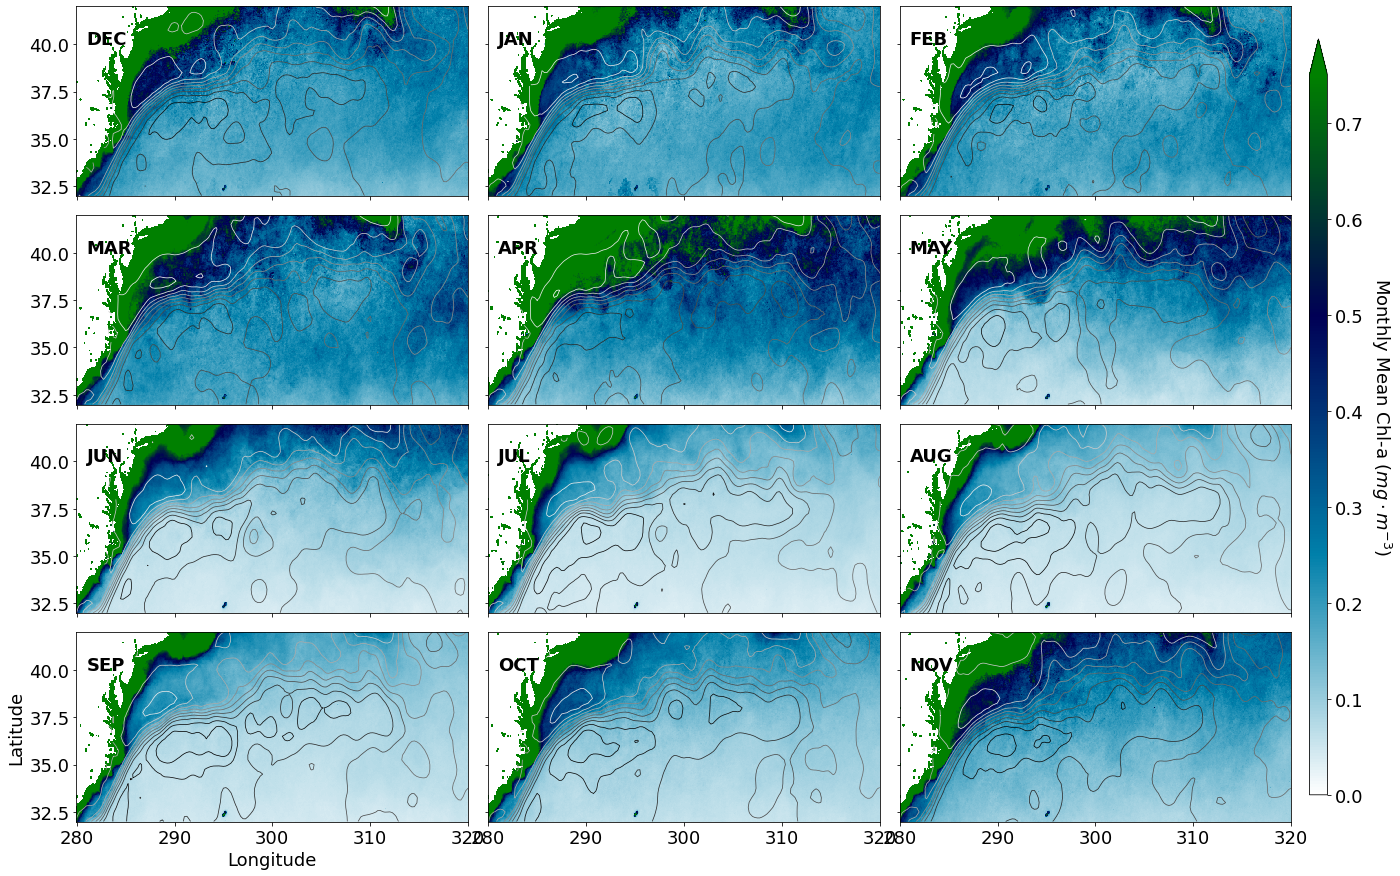

In [12]:
fig,ax = plt.subplots(4,3,figsize=(25,15))
plt.subplots_adjust(wspace=0.05, hspace=0.1) # make plots closer together

month_list = ['01','02','03','04','05','06','07','08','09','10','11','12']
months = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']

def plot_row_by_season(row_ind,array_of_months):
    i = 0
    for m in array_of_months:
        
        chl_avg = month_chl_avg[month_list.index(m)]
        plot = ax[row_ind,i].pcolormesh(chl_lon_edges[chl_lon_inds]+360,chl_lat_edges[chl_lat_inds],np.array(chl_avg)[chl_lat_inds[0],:][:,chl_lon_inds[0]],
                                        cmap='ocean_r',shading='nearest',vmin=0,vmax=0.75)
#        ax[row_ind,i].text(-78,40,months[month_list.index(m)],color='k',fontweight='bold')
        i += 1
    return plot

plot = plot_row_by_season(0,['12','01','02']) # Winter
plot = plot_row_by_season(1,['03','04','05']) # Spring
plot = plot_row_by_season(2,['06','07','08']) # Summer
plot = plot_row_by_season(3,['09','10','11']) # Fall

# Colorbar
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.81, 0.15, 0.01, 0.7]) #[left, bottom, width, height]
fig.colorbar(plot, cax=cbar_ax, extend='max')
cbar_ax.set_ylabel('Monthly Mean Chl-a ($mg\cdot m^{-3}$)', rotation=270)
cbar_ax.get_yaxis().labelpad = 30

def plot_adt_row_by_season(row_ind,array_of_months):
    i = 0
    for m in array_of_months:
        ADT_avg = np.load('/nfs/micklab005/jonesae/NP_2000_to_2020/CMEMS_data/climatology/dt_global_allsat_phy_l4_2010_2019_month_%s_AVG.npy'%(m))
        plot = ax[row_ind,i].contour(sample_sla_lon_edges[lon_inds],sample_sla_lat_edges[lat_inds],np.array(ADT_avg)[lat_inds[0],:][:,lon_inds[0]],
                                        cmap='binary',levels=10,vmin=-0.25,vmax=0.95,linewidths=0.75)
        ax[row_ind,i].text(281,40,months[month_list.index(m)],color='k',fontweight='bold')
        i += 1
    return plot

plot = plot_adt_row_by_season(0,['12','01','02']) # Winter
plot = plot_adt_row_by_season(1,['03','04','05']) # Spring
plot = plot_adt_row_by_season(2,['06','07','08']) # Summer
plot = plot_adt_row_by_season(3,['09','10','11']) # Fall


ax[3,0].set_xlabel('Longitude')
ax[3,0].set_ylabel('Latitude')

for row in range(4):
    for col in range(3):
        if row != 3:
            ax[row,col].set_xticklabels([])
        if col != 0:
            ax[row,col].set_yticklabels([])
        #ax[row,col].grid(True,c='k')

plt.show()

### Interpolate Chl to the CMEMS grid

This will yield a smaller file size and simplify the clustering. First crop chl data and convert from numpy array to xarray dataset.

In [13]:
lon_min,lon_max = 280, 320
lat_min,lat_max = 32, 42

sla_lon_centers = sample_sla.longitude
sla_lat_centers = sample_sla.latitude

sla_lon_inds = np.where((sla_lon_centers >= lon_min) & (sla_lon_centers <= lon_max))
sla_lat_inds = np.where((sla_lat_centers >= lat_min) & (sla_lat_centers <= lat_max))

sla_lon_centers_cropped = sla_lon_centers[sla_lon_inds]
sla_lat_centers_cropped = sla_lat_centers[sla_lat_inds]

In [14]:
month_ADT_avg = []
for m in month_list:
    ADT_avg = np.load('/nfs/micklab005/jonesae/NP_2000_to_2020/CMEMS_data/climatology/dt_global_allsat_phy_l4_2010_2019_month_%s_AVG.npy'%(m))
    month_ADT_avg.append(np.array(ADT_avg)[sla_lat_inds[0],:][:,sla_lon_inds[0]])
print(np.shape(month_ADT_avg))

(12, 40, 160)


In [15]:
sla_ds = xr.Dataset(data_vars={'ADT':(('month', 'latitude', 'longitude'),month_ADT_avg)}, 
                        coords={'month':range(1,13),
                                'latitude':sla_lat_centers_cropped,
                                'longitude':sla_lon_centers_cropped})
sla_ds

<xarray.Dataset>
Dimensions:    (latitude: 40, longitude: 160, month: 12)
Coordinates:
  * month      (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
  * latitude   (latitude) float32 32.12 32.38 32.62 32.88 ... 41.38 41.62 41.88
  * longitude  (longitude) float32 280.1 280.4 280.6 280.9 ... 319.4 319.6 319.9
Data variables:
    ADT        (month, latitude, longitude) float64 -0.03917 -0.08627 ... 0.2486

Now chl-a

In [16]:
chl_lon_centers = sample_chl.lon
chl_lat_centers = sample_chl.lat

chl_lon_inds = np.where((chl_lon_centers >= lon_min-360) & (chl_lon_centers <= lon_max-360)) # chl longitude is -180 to 180 
chl_lat_inds = np.where((chl_lat_centers >= lat_min) & (chl_lat_centers <= lat_max))

chl_lon_centers_cropped = chl_lon_centers[chl_lon_inds]+360
chl_lat_centers_cropped = chl_lat_centers[chl_lat_inds]
chl_cropped = np.array(month_chl_avg)[:,chl_lat_inds[0],:][:,:,chl_lon_inds[0]]

In [17]:
print(len(chl_lon_centers_cropped))
print(len(chl_lat_centers_cropped))
print(np.shape(chl_cropped))

960
240
(12, 240, 960)


In [18]:
chl_ds = xr.Dataset(data_vars={'chl':(('month', 'lat', 'lon'),chl_cropped)}, 
                        coords={'month':range(1,13),
                                'lat':chl_lat_centers_cropped,
                                'lon':chl_lon_centers_cropped})
chl_ds

<xarray.Dataset>
Dimensions:  (lat: 240, lon: 960, month: 12)
Coordinates:
  * month    (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 41.98 41.94 41.9 41.85 ... 32.15 32.1 32.06 32.02
  * lon      (lon) float64 280.0 280.1 280.1 280.1 ... 319.9 319.9 319.9 320.0
Data variables:
    chl      (month, lat, lon) float32 nan nan nan nan ... 0.1296 0.132 0.1291

Smooth chl-a to same grid as the ADT

In [19]:
chl_ds_low_res = chl_ds.interp(lat=sla_ds.latitude, lon=sla_ds.longitude, method='linear', kwargs={"fill_value": "extrapolate"}) # fill value extrapolates to the edges of the map
chl_ds_low_res

<xarray.Dataset>
Dimensions:    (latitude: 40, longitude: 160, month: 12)
Coordinates:
  * month      (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
    lat        (latitude) float32 32.12 32.38 32.62 32.88 ... 41.38 41.62 41.88
    lon        (longitude) float32 280.1 280.4 280.6 280.9 ... 319.4 319.6 319.9
  * latitude   (latitude) float32 32.12 32.38 32.62 32.88 ... 41.38 41.62 41.88
  * longitude  (longitude) float32 280.1 280.4 280.6 280.9 ... 319.4 319.6 319.9
Data variables:
    chl        (month, latitude, longitude) float64 0.5831 0.6024 ... 0.3132

In [20]:
chl_ds_low_res = chl_ds_low_res.reset_coords(['lat','lon'], drop=True)

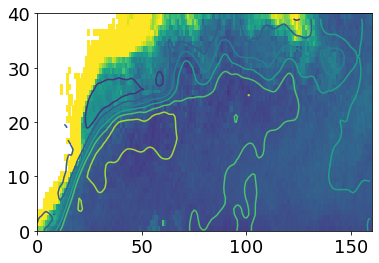

In [21]:
plt.pcolormesh(chl_ds_low_res.chl[0],vmin=0,vmax=0.75)
plt.contour(sla_ds.ADT[0])

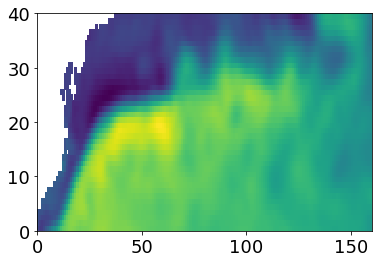

In [22]:
plt.pcolormesh(sla_ds.ADT[0])

### Save Monthly Avg Data

Going to transfer to CryoCloud

In [56]:
# save_dir = '/pool001/jonesae/PACEhackweek/'
save_dir = '/home/jonesae/orcd/pool/PACEhackweek/'
sla_ds.to_netcdf(save_dir + 'monthly_ADT_avg_2000_to_2020_CMEMS_dt_global_allsat_Gulf_Stream_crop_lat_32_42_lon_280_320.nc')
chl_ds_low_res.chl.to_netcdf(save_dir + 'monthly_chl_avg_2000_to_2020_OCCCI-4km_GEO_PML_OCx-201612-fv6.0_Gulf_Stream_crop_lat_32_42_lon_280_320.nc')